# Filter basis functions

To parameterize spherical discrete-continuous (DISCO) convolutions, we need to pick suitable basis functions. Currently, torch-harmonics supports 3 different basis types:

* Picewise Linear basis functions (Similar to hat functions in finite element methods)
* Morlet-wavelet-like basis functions defined on the sphere
* Zernike polynomials

This notebook outlines depicts the different types of basis functions.

In [1]:
import math

import numpy as np
import torch

import matplotlib.pyplot as plt
cmap = plt.cm.RdBu

from torch_harmonics.filter_basis import get_filter_basis

## Piecewise linear basis on a disk

We start off with piecewise linear basis functions defined on a disk.

In [12]:
fb = get_filter_basis((5, 4), "piecewise linear")

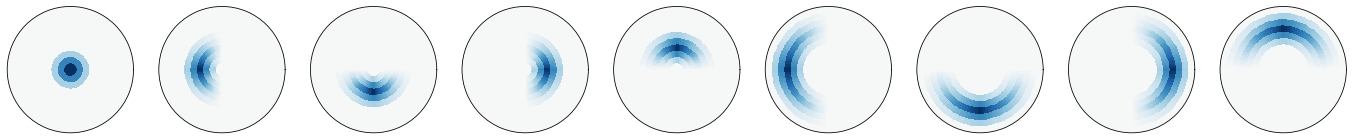

In [13]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 10)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(24,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].pcolormesh(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max())
    ax[k].set_xticks([])
    ax[k].set_yticks([])

## Wavelet style basis

In [4]:
nmax = mmax = 3
fb = get_filter_basis((nmax, mmax), "harmonic")

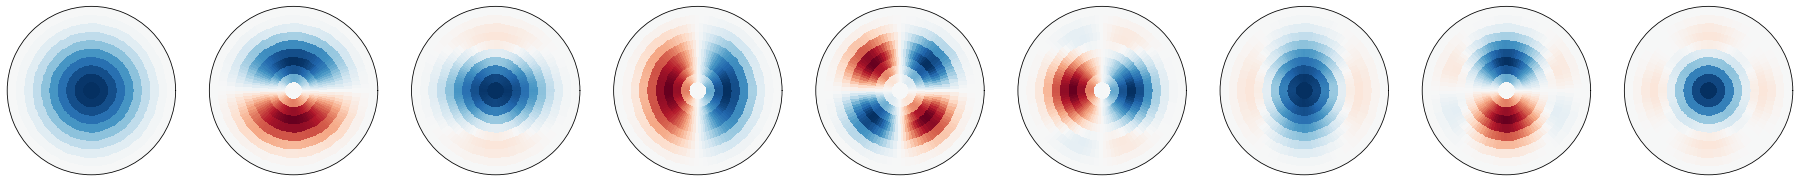

In [5]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 10)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(32,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].pcolormesh(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max())
    ax[k].set_xticks([])
    ax[k].set_yticks([])

## Zernike polynomials

for more info read [https://en.wikipedia.org/wiki/Zernike_polynomials](https://en.wikipedia.org/wiki/Zernike_polynomials)

In [6]:
nmax = 4
fb = get_filter_basis(nmax, "zernike")

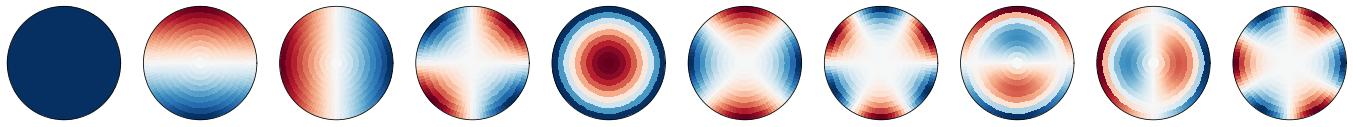

In [7]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 10)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(24,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].pcolormesh(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max())
    ax[k].set_xticks([])
    ax[k].set_yticks([])

## Fourier-Bessel Basis

The Fourier-Bessel Basis functions on a disk are defined as

$$
\Psi_{m, n} (r, \theta) = J_m(\alpha_{m, n} r) \cos(m \theta)
$$

Unlike, the Zernike polynomials, the Fourier-Bessel basis functiosn vanish smoothly to $0$ at the boundary, which is advantageous for filtering and leakage purposes.

In [8]:
kernel_shape = (3,2)
fb = get_filter_basis(kernel_shape=kernel_shape, basis_type="fourier-bessel")

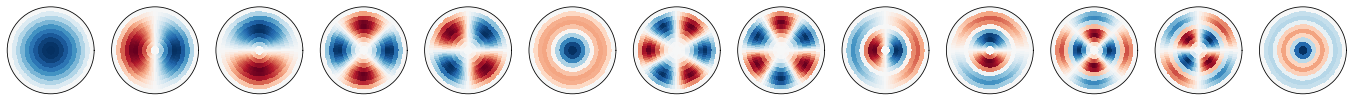

In [9]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 10)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(24,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].pcolormesh(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max())
    ax[k].set_xticks([])
    ax[k].set_yticks([])